# LDA
* Vectorization with BoW
* LDA for topic modeling
* Model evaluation with perplexity, coherence and topic diversity
* Visualization with pyLDAvis <br>
--> Present topic clusters and top words for optimal k <br>
--> Plot distribution of posts across topics & topic probability

In [14]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from gensim.models import CoherenceModel
from gensim.corpora import Dictionary

from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import pyLDAvis
import pyLDAvis.lda_model

sns.set_theme(style='whitegrid', context='paper')

In [15]:
# Load preprocessed data
df = pd.read_pickle("data/preprocessed_data.pkl")
df.head(5)

,id,author,question,link_flair_css_class,link_flair_text,description,created_utc,year,retrieved_on,org_post,language,clean_question,clean_desc,question_tokens,desc_tokens,q_tuple,d_tuple,post_tokens,clean_text
0,421zyl,[deleted],How is time defined at the big bang?,physics,Physics,[removed],2016-01-21 20:58:09,2016,2016-02-09 12:21:05,How is time defined at the big bang? [removed],en,how is time defined at the big bang,removed,"[time, define, big, bang]",[],"(time, define, big, bang)",(),"[time, define, big_bang]",time define big_bang
1,4r857d,[deleted],UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,[removed],2016-07-04 17:05:51,2016,2016-09-03 18:04:14,UFO best scientific explanation. Atmospherical...,en,ufo best scientific explanation atmospherical ...,removed,"[ufo, good, scientific, explanation, atmospher...",[],"(ufo, good, scientific, explanation, atmospher...",(),"[ufo, good, scientific_explanation, atmospheri...",ufo good scientific_explanation atmospherical ...
2,4r0zwj,De_La_Soul_,It's a commonly known fact that metals oxidize...,chem,Chemistry,,2016-07-03 06:40:06,2016,2016-09-02 17:31:58,It's a commonly known fact that metals oxidize...,en,it s a commonly known fact that metals oxidize...,,"[s, commonly, know, fact, metal, oxidize, poss...",[],"(s, commonly, know, fact, metal, oxidize, poss...",(),"[s, commonly, know, fact, metal, oxidize, poss...",s commonly know fact metal oxidize possible di...
3,540ohz,MacShakeIt,"China builds large telescope, but i have a que...",astro,Astronomy,[removed],2016-09-22 19:17:55,2016,2016-10-14 11:02:04,"China builds large telescope, but i have a que...",en,china builds large telescope but i have a ques...,removed,"[china, build, large, telescope, question]",[],"(china, build, large, telescope, question)",(),"[china, build, large, telescope, question]",china build large telescope question
4,4r191k,[deleted],Geoscientists: Is there any current research i...,geo,Planetary Sci.,[removed],2016-07-03 08:26:38,2016,2016-09-02 17:34:09,Geoscientists: Is there any current research i...,en,geoscientists is there any current research in...,removed,"[geoscientist, current, research, project, sho...",[],"(geoscientist, current, research, project, sho...",(),"[geoscientist, current, research_project, shor...",geoscientist current research_project shortfal...


## BoW Vectorization

In [16]:
vectorizer = CountVectorizer(
    max_features=10000,
    ngram_range=(1, 1),
    min_df=5,               # ignore words in < 5 docs
    max_df=0.8              # ignore words in > 80% of docs
)
X = vectorizer.fit_transform(df['clean_text'])

# Vocabulary size
print(len(vectorizer.vocabulary_))
# Feature names
print(vectorizer.get_feature_names_out())
# Sparse feature matrix
print(X)

10000
['00' '00_00' '00_year' ... 'zoology' 'zoom' 'zygote']
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3619213 stored elements and shape (591194, 10000)>
  Coords	Values
  (0, 9137)	1
  (0, 2485)	1
  (0, 1086)	1
  (1, 9369)	1
  (1, 4090)	1
  (1, 7910)	1
  (1, 3278)	1
  (1, 5747)	1
  (2, 1929)	1
  (2, 5129)	1
  (2, 3457)	1
  (2, 5737)	1
  (2, 6483)	1
  (2, 6948)	1
  (2, 3935)	1
  (3, 1706)	1
  (3, 1374)	1
  (3, 5172)	1
  (3, 8986)	1
  (3, 7286)	1
  (4, 2342)	1
  (4, 7619)	1
  (4, 5093)	1
  (4, 5821)	1
  (4, 3070)	1
  :	:
  (591189, 7286)	1
  (591189, 9571)	1
  (591189, 7712)	1
  (591189, 4023)	1
  (591189, 7049)	1
  (591189, 669)	1
  (591189, 469)	1
  (591189, 2533)	2
  (591189, 5947)	1
  (591189, 445)	1
  (591190, 3306)	1
  (591190, 2040)	1
  (591191, 9137)	1
  (591191, 2830)	1
  (591192, 3431)	1
  (591192, 5326)	1
  (591192, 299)	1
  (591192, 6529)	1
  (591192, 1764)	1
  (591192, 4454)	1
  (591192, 9227)	1
  (591193, 2946)	1
  (591193, 8010)	1
  (591193, 6770)	1
  (5

## Hyperparameter Tuning
### Finding the best values for k

In [17]:
dictionary = Dictionary(df['post_tokens'])

In [18]:
# LDA model training
def train_lda(k, X):
    """Train LDA model with given number of topics and feature matrix."""

    lda = LatentDirichletAllocation(
        n_components=k,
        learning_method="online",
        max_iter=10,
        random_state=42,
        n_jobs=-1,
        batch_size=32768,
        evaluate_every=-1
    )
    lda.fit(X)
    return lda

In [19]:
# Model evaluation
def evaluate_model(lda, X, vectorizer, texts, dictionary, top_n=10):
    """Evaluate LDA model using coherence, perplexity, and topic diversity."""

    # Perplexity
    perplexity = lda.perplexity(X)

    # Extract topics
    feature_names = np.array(vectorizer.get_feature_names_out())

    topics = []

    for topic in lda.components_:
        top_words = feature_names[topic.argsort()[-top_n:]]
        topics.append(list(top_words))

    # Coherence
    cm = CoherenceModel(
        topics=topics,
        texts=texts,
        dictionary=dictionary,
        coherence="c_v"
    )

    coherence = cm.get_coherence()

    # Topic diversity
    all_topic_words = []

    for topic in topics:
        all_topic_words.extend(topic)

    diversity = len(set(all_topic_words)) / len(all_topic_words)

    return coherence, perplexity, diversity

In [20]:
# Plotting evaluation metrics
def plot_lda_metrics(results, k_min, k_max, step):
    """Plot evaluation metrics for LDA models across different numbers of topics."""
    
    # Extract values from results
    k_vals = [r[0] for r in results]
    coherence = np.array([r[1] for r in results]).reshape(-1, 1)
    perplexity = np.array([r[2] for r in results]).reshape(-1, 1)
    diversity = np.array([r[3] for r in results]).reshape(-1, 1)

    # Build summary table
    summary = pd.DataFrame({
        'k': k_vals,
        'Coherence': coherence.flatten(),
        'Diversity': diversity.flatten(),
        'Perplexity': perplexity.flatten()
    })

    # Normalize metrics
    scaler = MinMaxScaler()
    summary[['Coherence_norm', 'Diversity_norm', 'Perplexity_norm']] = scaler.fit_transform(
        summary[['Coherence', 'Diversity', 'Perplexity']]
    )

    # Invert perplexity
    summary['Perplexity_norm'] = 1 - summary['Perplexity_norm']

    # Plot
    plt.figure(figsize=(10, 6))

    # Plot metrics
    plt.plot(k_vals, summary['Coherence_norm'], marker='o', label='Coherence')
    plt.plot(k_vals, summary['Perplexity_norm'], marker='s', label='Perplexity (inverted)')
    plt.plot(k_vals, summary['Diversity_norm'], marker='^', label='Topic Diversity')

    # Labels and title
    plt.xlabel("Number of Topics (k)")
    plt.ylabel("Normalized Score")
    plt.title("LDA Model Evaluation")

    # Legend and grid
    plt.legend()
    plt.grid(visible=True)
    plt.gca().xaxis.set_major_locator(plt.MultipleLocator(5))

    # Despine
    for spine in ['top', 'right', 'bottom', 'left']:
        plt.gca().spines[spine].set_visible(False)

    plt.tight_layout()

    # Save viz
    plt.savefig(f'viz/LDA_evaluation_metrics-{k_min}-{k_max}-{step}.png', dpi=300)
    plt.show()

    # Print table with evaluation scores
    print(summary[['k', 'Coherence', 'Diversity', 'Perplexity', 'Coherence_norm', 'Diversity_norm', 'Perplexity_norm']])

Training LDA for k=2
Training LDA for k=3
Training LDA for k=4
Training LDA for k=5
Training LDA for k=6
Training LDA for k=7
Training LDA for k=8
Training LDA for k=9
Training LDA for k=10
Training LDA for k=11
Training LDA for k=12
Training LDA for k=13
Training LDA for k=14
Training LDA for k=15
Training LDA for k=16
Training LDA for k=17
Training LDA for k=18
Training LDA for k=19
Training LDA for k=20
Training LDA for k=21
Training LDA for k=22
Training LDA for k=23
Training LDA for k=24
Training LDA for k=25
Training LDA for k=26
Training LDA for k=27
Training LDA for k=28
Training LDA for k=29
Training LDA for k=30
Training LDA for k=31
Training LDA for k=32
Training LDA for k=33
Training LDA for k=34
Training LDA for k=35
Training LDA for k=36
Training LDA for k=37
Training LDA for k=38
Training LDA for k=39
Training LDA for k=40
Training LDA for k=41
Training LDA for k=42
Training LDA for k=43
Training LDA for k=44
Training LDA for k=45
Training LDA for k=46
Training LDA for k

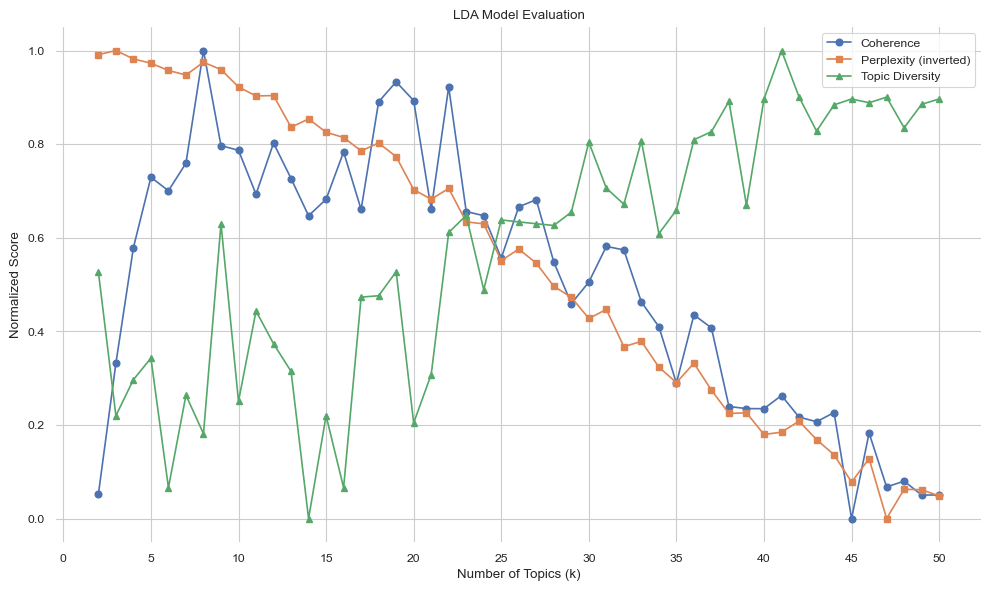

     k  Coherence  Diversity   Perplexity  Coherence_norm  Diversity_norm  \
0    2   0.482529   0.900000  2416.804166        0.051653        0.527331   
1    3   0.525685   0.866667  2405.800337        0.331536        0.219721   
2    4   0.563799   0.875000  2428.079348        0.578725        0.296624   
3    5   0.586998   0.880000  2439.598006        0.729181        0.342765   
4    6   0.582564   0.850000  2458.848157        0.700424        0.065916   
5    7   0.591641   0.871429  2471.030835        0.759296        0.263666   
6    8   0.628756   0.862500  2437.029074        1.000000        0.181270   
7    9   0.597432   0.911111  2456.596810        0.796853        0.629868   
8   10   0.595875   0.870000  2502.724491        0.786752        0.250482   
9   11   0.581396   0.890909  2526.854427        0.692853        0.443438   
10  12   0.598270   0.883333  2525.732370        0.802283        0.373526   
11  13   0.586592   0.876923  2610.136692        0.726546        0.314371   

In [21]:
k_min = 2
k_max = 50
step = 1
k_values = range(k_min, k_max + 1, step)

results = []

for k in k_values:
    print(f"Training LDA for k={k}")

    # Fit LDA model
    lda = train_lda(k, X)

    # Get evaluation metrics
    coherence, perplexity, diversity = evaluate_model(
    lda, X, vectorizer, df['post_tokens'], dictionary
    )

    results.append((k, coherence, perplexity, diversity))

plot_lda_metrics(results, k_min=k_min, k_max=k_max, step=step)

From the plotted range it can be seen that the inverted perplexity score decreases with increasing *k* carrying little information on the optimal value of *k*. The coherence score increases sharply in the beginning and shows three peaks at *k = 8*, *k = 19* and *k = 22*. A higher coherence score is desirable for sematically meaniful topics and thus the most important metric in this case. As an additional metric topic diversity was plotted to measure the disctinctness of topics. Unlike the perplexity score, it is volatile with small *k*s and steadily increases with larger values of *k*. As the most promising value of *k = 22* is selected.

## Final Run with Best *k*

In [27]:
def get_topic_labels(model, vectorizer, n_words=5):
    """Generate formatted labels for each topic based on the top words for each topic."""

    words = vectorizer.get_feature_names_out()
    topic_labels = {}

    for i, topic in enumerate(model.components_):
        top_words = [words[j] for j in topic.argsort()[-n_words:][::-1]]
        topic_labels[i] = f"Topic {i}: " + " | ".join(top_words)

    return topic_labels

In [28]:
def get_top_words(model, vectorizer, n_top=15):
    """Return top words for each topic as list of lists."""

    feature_names = vectorizer.get_feature_names_out()
    topics = []
    
    for comp in model.components_:
        top_idx = np.argsort(comp)[::-1][:n_top]
        topics.append([feature_names[i] for i in top_idx])
    
    return topics

In [29]:
def plot_bars_topic_distribution(k):
    """
    Create a bar plot showing the distribution of documents across topics, with topic labels based on top words.
    """

    # Set color
    color = plt.colormaps["tab20b"](0)

    # Create plot
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.countplot(
        data=df,
        y=f"topic_label_k{k}",
        order=df[f'topic_label_k{k}'].value_counts().index,
        ax=ax,
        color=color
    )

    # Formatting
    ax.set_title(f"Publications by Topic (k={k})", fontsize=16)
    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.tick_params(axis='y', labelsize=11)
    ax.tick_params(axis='x', labelsize=11)

    ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

    # Despine
    for spine in ['top', 'right', 'bottom']:
        ax.spines[spine].set_visible(False)

    ax.grid(axis="y", visible=False)

    plt.tight_layout()

    # Save and show
    plt.savefig(f"viz/LDA_posts_per_topic_k{k}.png", dpi=300)
    plt.show()

In [30]:
def plot_box_topic_confidence(k):
    """
    Plot boxplot of topic probabilities with top words as legend.
    """

    # Set color
    color = plt.colormaps["tab20b"](16)

    # Create plot
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(
        data=df,
        x=f"topic_k{k}",
        y=f"topic_prob_k{k}",
        color=color,
        ax=ax
    )

    # Titles and labels
    ax.set_title("Topic Probability Distribution per Topic", fontsize=16)
    ax.set_xlabel("Topic", fontsize=12)
    ax.set_ylabel("Topic Confidence", fontsize=12)

    # Despine
    for spine in ['top', 'right', 'bottom']:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()

    # Save and show
    plt.savefig(f"viz/LDA_topic_confidence_k{k}.png", dpi=300)
    plt.show()

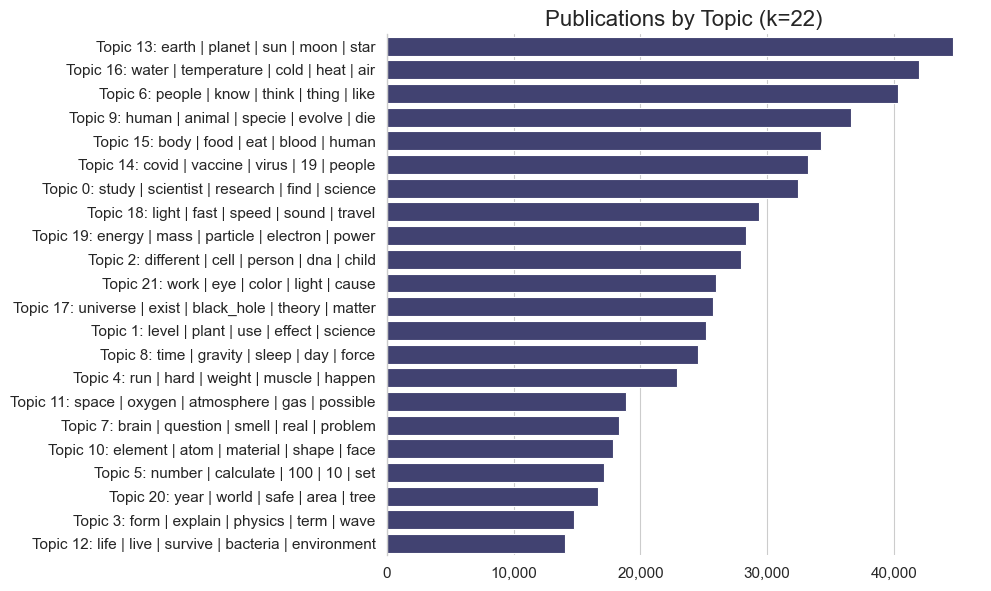

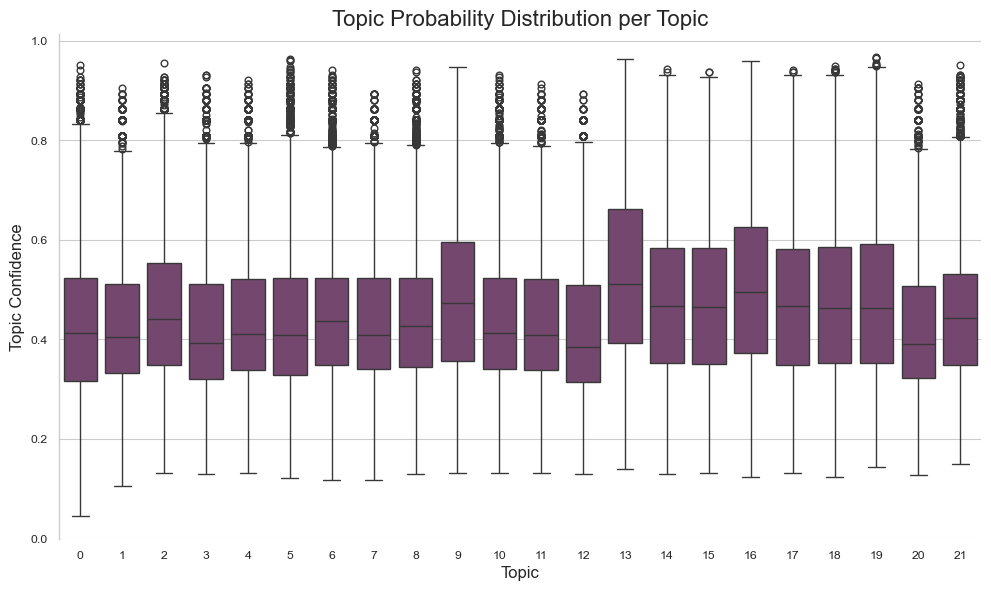

In [31]:
k = 22

lda = train_lda(k, X)
doc_topics = lda.transform(X)

# Assign topics to documents and add to df
df[f"topic_k{k}"] = doc_topics.argmax(axis=1)
df[f"topic_prob_k{k}"] = doc_topics.max(axis=1)

# Get topic labels
topic_labels = get_topic_labels(lda, vectorizer)
df[f'topic_label_k{k}'] = df[f"topic_k{k}"].map(topic_labels)

# Get and save top words
top_words = get_top_words(lda, vectorizer, n_top=15)
top_words_df = pd.DataFrame({
    f"Topic {i}": words for i, words in enumerate(top_words)
})
top_words_df.to_csv(f"topics/LDA_top_words_k{k}.csv", index=False)

# Plot topic distribution
plot_bars_topic_distribution(k=k)

# Plot topic confidence
plot_box_topic_confidence(k=k)

# pyLDAvis visualization
viz = pyLDAvis.lda_model.prepare(lda, X, vectorizer)
pyLDAvis.display(viz)